In [1]:
import numpy as np
import pandas as pd

In [2]:
# random seed
np.random.seed(42)

# imbalanced data set
set1no= 900
set2no= 100

In [54]:
## dataframe with imbalanced data set
df1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=set1no),
    'feature_2': np.random.normal(loc=0, scale=1, size=set1no),
    'target': [0] * set1no
})

df2 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=set2no),
    'feature_2': np.random.normal(loc=2, scale=1, size=set2no),
    'target': [1] * set2no
})

In [55]:
df= pd.concat([df1,df2]).reset_index(drop=True)

In [56]:
df

,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0
...,...,...,...
995,3.001632,2.028458,1
996,3.393455,-0.077812,1
997,2.710549,1.679702,1
998,2.429341,3.643378,1


In [57]:
df["target"].unique()

array([0, 1])

In [11]:
df_minority = df[df["target"]==1]
df_majority = df[df["target"]==0]

In [29]:
from sklearn.utils import resample
df_minority_upsampled = resample(df_minority, replace=True , n_samples=len(df_majority),
                                 random_state=42
                                )


In [30]:
df_minority_unsampled

,feature_1,feature_2,target
951,3.775311,3.261922,1
992,1.563614,3.188913,1
914,1.731469,0.198942,1
971,1.785079,-0.940389,1
960,1.865691,1.945106,1
...,...,...,...
952,0.806363,1.094268,1
965,0.337508,2.089581,1
976,1.437832,3.124113,1
942,1.451275,2.269127,1


In [31]:
df_minority_upsampled.shape

(900, 3)

In [32]:
df_minority.shape

(100, 3)

In [33]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,3.775311,3.261922,1
992,1.563614,3.188913,1
914,1.731469,0.198942,1
971,1.785079,-0.940389,1
960,1.865691,1.945106,1


In [34]:
df_upsampled = pd.concat([df_majority,df_minority_upsampled])

In [35]:
df_upsampled

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
952,0.806363,1.094268,1
965,0.337508,2.089581,1
976,1.437832,3.124113,1
942,1.451275,2.269127,1


In [36]:
df_upsampled["target"].value_counts()

target
0    900
1    900
Name: count, dtype: int64

In [37]:
df_majority_downsampled = resample(df_majority , replace=True , n_samples=len(df_minority),
                                   random_state=42
                                  )

In [38]:
df_majority_downsampled

,feature_1,feature_2,target
102,-0.342715,0.059630,0
435,0.074095,-0.337086,0
860,0.202923,1.639965,0
270,1.441273,0.758929,0
106,1.886186,0.895193,0
...,...,...,...
201,0.560785,-2.896255,0
269,0.130741,0.853416,0
862,1.547505,0.075434,0
815,-1.485560,-0.090533,0


In [39]:
df_majority

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
895,0.648710,-0.751969,0
896,-0.167118,-0.319054,0
897,0.146714,-0.796026,0
898,1.206509,1.076007,0


In [46]:
df_downsampled = pd.concat([df_minority , df_majority_downsampled])

In [47]:
df_downsampled.shape

(200, 3)

In [48]:
df_majority_downsampled["target"].value_counts()

target
0    100
Name: count, dtype: int64

In [50]:
df_downsampled["target"].value_counts()

target
1    100
0    100
Name: count, dtype: int64

In [51]:
df

,feature_1,feature_2,target
0,0.496714,0.368673,0
1,-0.138264,-0.393339,0
2,0.647689,0.028745,0
3,1.523030,1.278452,0
4,-0.234153,0.191099,0
...,...,...,...
995,1.629989,3.070150,1
996,1.741204,1.973479,1
997,3.598647,1.118125,1
998,2.560919,1.836933,1


In [53]:
import matplotlib.pyplot as plt

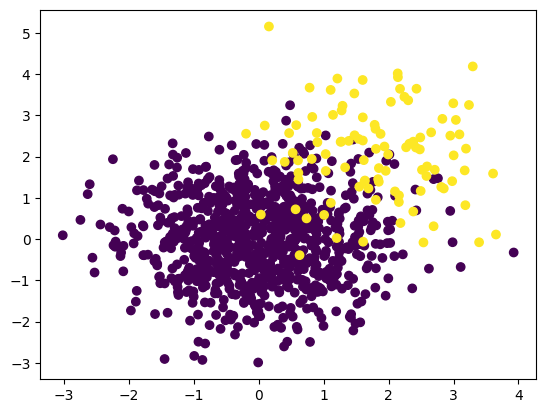

In [61]:
plt.scatter(df["feature_1"], df["feature_2"] , c=df["target"])
plt.show()

In [62]:
#SMOTE (Synthetic Minority Over-sampling Technique)

In [63]:
df

,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0
...,...,...,...
995,3.001632,2.028458,1
996,3.393455,-0.077812,1
997,2.710549,1.679702,1
998,2.429341,3.643378,1


In [64]:
from imblearn.over_sampling import SMOTE

In [65]:
oversample = SMOTE()

In [66]:
(X ,y ) = oversample.fit_resample(df[["feature_1","feature_2"]] , df["target"])

In [72]:
oversample_df = pd.concat([X , y],axis=1)

In [73]:
oversample_df

,feature_1,feature_2,target
0,-0.675178,-0.045512,0
1,-0.144519,-0.424236,0
2,-0.792420,-0.569833,0
3,-0.307962,0.329509,0
4,-1.893615,-1.517174,0
...,...,...,...
1795,1.680071,1.253121,1
1796,2.794455,2.849616,1
1797,2.225699,3.529741,1
1798,2.161328,3.764309,1


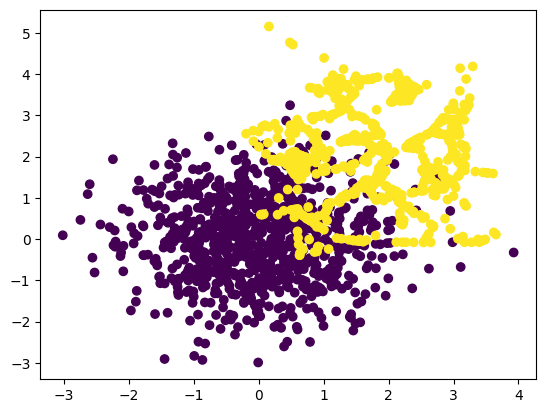

In [77]:
plt.scatter(oversample_df["feature_1"] , oversample_df["feature_2"] , c=oversample_df["target"])
plt.show()

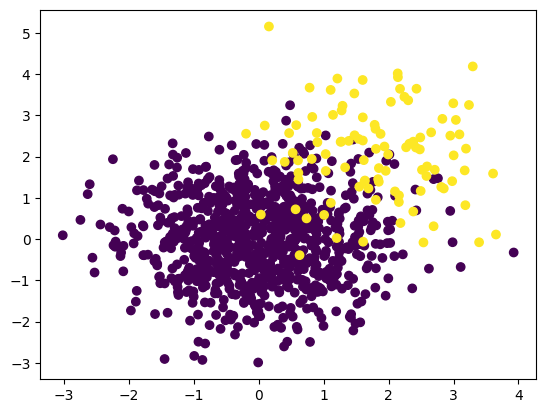

In [76]:
plt.scatter(df["feature_1"], df["feature_2"] , c=df["target"])
plt.show()